In [3]:
# Cell 1: Install required libraries
!pip install -q tensorflow pandas numpy scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Cell 2: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# Cell 4: Load dataset
df = pd.read_csv("IMDB Dataset.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (50000, 2)

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
# Cell 5: Inspect dataset
print(df.info())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Missing values:
review       0
sentiment    0
dtype: int64


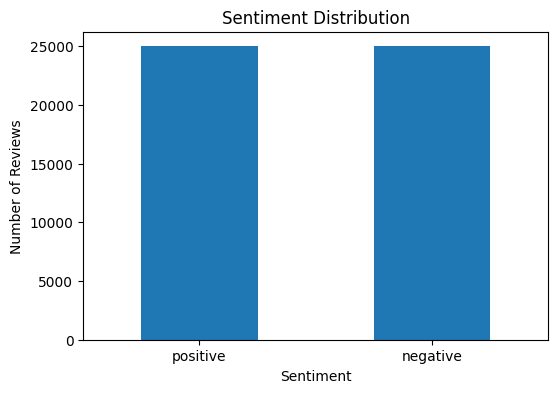

In [7]:
# Cell 6: Visualize sentiment distribution
df["sentiment"].value_counts().plot(kind="bar", figsize=(6, 4))
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [8]:
# Cell 7: Convert labels to numerical values
df["sentiment"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

print(df.head())
print("\nEncoded labels:", df["sentiment"].unique())

                                              review  sentiment
0  One of the other reviewers has mentioned that ...          1
1  A wonderful little production. <br /><br />The...          1
2  I thought this was a wonderful way to spend ti...          1
3  Basically there's a family where a little boy ...          0
4  Petter Mattei's "Love in the Time of Money" is...          1

Encoded labels: [1 0]


In [9]:
# Cell 8: Separate input and output
X = df["review"].values
y = df["sentiment"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000,)
y shape: (50000,)


In [10]:
# Cell 9: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 40000
Testing samples: 10000


In [11]:
# Cell 10: Tokenization
max_words = 10000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

print("Total unique words found:", len(tokenizer.word_index))
print("Words used by the model:", max_words)

Total unique words found: 111959
Words used by the model: 10000


In [12]:
# Cell 11: Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Original review:")
print(X_train[0])

print("\nTokenized review:")
print(X_train_seq[0])

Original review:
I caught this little gem totally by accident back in 1980 or '81. I was at a revival theatre to see two old silly sci-fi movies. The theatre was packed full and (with no warning) they showed a bunch of sci-fi short spoofs (to get us in the mood). Most were somewhat amusing but THIS came on and, within seconds, the audience was in hysterics! The biggest laugh came when they showed "Princess Laia" having huge cinnamon buns instead of hair on her head. She looks at the camera, gives a grim smile and nods. That made it even funnier! You gotta see "Chewabacca" played by what looks like a Muppet! It was extremely silly and stupid...but I couldn't stop laughing. Most of the dialogue was drowned out because of all the laughter. Also if you know "Star Wars" pretty well it's even funnier--they deliberately poke fun at some of the dialogue. This REALLY works with an audience! A definite 10!

Tokenized review:
[11, 1055, 12, 120, 1506, 458, 32, 1609, 143, 9, 4301, 39, 1, 11, 14, 3

In [13]:
# Cell 12: Padding
max_length = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

Training shape: (40000, 200)
Testing shape: (10000, 200)


In [14]:
# Cell 13: Create Simple RNN model
def create_rnn_model():
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=128),
        SimpleRNN(128),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [15]:
# Cell 14: Create LSTM model
def create_lstm_model():
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=128),
        LSTM(128),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [16]:
# Cell 15: Create GRU model
def create_gru_model():
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=128),
        GRU(128),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [17]:
# Cell 16: Initialize all three models
rnn_model = create_rnn_model()
lstm_model = create_lstm_model()
gru_model = create_gru_model()

print("Models created successfully.")

Models created successfully.


In [18]:
# Cell 17: Display model architectures
print("===== RNN =====")
rnn_model.summary()

print("\n===== LSTM =====")
lstm_model.summary()

print("\n===== GRU =====")
gru_model.summary()

===== RNN =====


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Cell 18: Train RNN
start_time = time.time()

rnn_history = rnn_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.20,
    verbose=1
)

rnn_time = time.time() - start_time
print(f"RNN training time: {rnn_time:.2f} seconds")

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.4973 - loss: 0.7214 - val_accuracy: 0.4984 - val_loss: 0.6932
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.5103 - loss: 0.7015 - val_accuracy: 0.5002 - val_loss: 0.6978
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.5462 - loss: 0.6837 - val_accuracy: 0.5013 - val_loss: 0.6956
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.5606 - loss: 0.6726 - val_accuracy: 0.5189 - val_loss: 0.7108
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 90ms/step - accuracy: 0.5946 - loss: 0.6409 - val_accuracy: 0.5173 - val_loss: 0.7204
RNN training time: 105.00 seconds


In [20]:
# Cell 19: Train LSTM
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.20,
    verbose=1
)

lstm_time = time.time() - start_time
print(f"LSTM training time: {lstm_time:.2f} seconds")

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 61s 117ms/step - accuracy: 0.5407 - loss: 0.6875 - val_accuracy: 0.6225 - val_loss: 0.6477
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.5727 - loss: 0.6694 - val_accuracy: 0.5428 - val_loss: 0.6871
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 74ms/step - accuracy: 0.6219 - loss: 0.6343 - val_accuracy: 0.6543 - val_loss: 0.6411
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 77ms/step - accuracy: 0.8030 - loss: 0.4532 - val_accuracy: 0.8149 - val_loss: 0.4142
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 78ms/step - accuracy: 0.8720 - loss: 0.3221 - val_accuracy: 0.8464 - val_loss: 0.3577
LSTM training time: 213.68 seconds


In [21]:
# Cell 20: Train GRU
start_time = time.time()

gru_history = gru_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.20,
    verbose=1
)

gru_time = time.time() - start_time
print(f"GRU training time: {gru_time:.2f} seconds")

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 68ms/step - accuracy: 0.5141 - loss: 0.6926 - val_accuracy: 0.5304 - val_loss: 0.6904
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 68ms/step - accuracy: 0.5845 - loss: 0.6594 - val_accuracy: 0.7915 - val_loss: 0.4824
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.8691 - loss: 0.3153 - val_accuracy: 0.8806 - val_loss: 0.2827
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 68ms/step - accuracy: 0.9314 - loss: 0.1881 - val_accuracy: 0.8758 - val_loss: 0.3073
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 68ms/step - accuracy: 0.9588 - loss: 0.1214 - val_accuracy: 0.8756 - val_loss: 0.3481
GRU training time: 170.48 seconds


In [22]:
# Cell 21: Evaluate all models
rnn_loss, rnn_accuracy = rnn_model.evaluate(X_test_pad, y_test, verbose=0)
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test_pad, y_test, verbose=0)
gru_loss, gru_accuracy = gru_model.evaluate(X_test_pad, y_test, verbose=0)

print(f"RNN  - Loss: {rnn_loss:.4f}, Accuracy: {rnn_accuracy:.4f}")
print(f"LSTM - Loss: {lstm_loss:.4f}, Accuracy: {lstm_accuracy:.4f}")
print(f"GRU  - Loss: {gru_loss:.4f}, Accuracy: {gru_accuracy:.4f}")

RNN  - Loss: 0.7234, Accuracy: 0.5076
LSTM - Loss: 0.3582, Accuracy: 0.8467
GRU  - Loss: 0.3764, Accuracy: 0.8667


In [23]:
# Cell 22: Generate predictions
rnn_prob = rnn_model.predict(X_test_pad, verbose=0).flatten()
lstm_prob = lstm_model.predict(X_test_pad, verbose=0).flatten()
gru_prob = gru_model.predict(X_test_pad, verbose=0).flatten()

rnn_pred = (rnn_prob >= 0.5).astype(int)
lstm_pred = (lstm_prob >= 0.5).astype(int)
gru_pred = (gru_prob >= 0.5).astype(int)

print("Predictions generated.")

Predictions generated.


In [24]:
# Cell 23: Calculate evaluation metrics
model_predictions = {
    "RNN": rnn_pred,
    "LSTM": lstm_pred,
    "GRU": gru_pred
}

results = []

for name, predictions in model_predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,RNN,0.5076,0.514286,0.2736,0.357180
1,LSTM,0.8467,0.850273,0.8416,0.845914
2,GRU,0.8667,0.879843,0.8494,0.864353


In [25]:
# Cell 24: Add loss and training time
results_df["Test Loss"] = [rnn_loss, lstm_loss, gru_loss]
results_df["Training Time (sec)"] = [rnn_time, lstm_time, gru_time]

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Test Loss",
        "Training Time (sec)"
    ]
]

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Test Loss,Training Time (sec)
0,RNN,0.5076,0.514286,0.2736,0.357180,0.723413,105.004347
1,LSTM,0.8467,0.850273,0.8416,0.845914,0.358209,213.682311
2,GRU,0.8667,0.879843,0.8494,0.864353,0.376431,170.483482


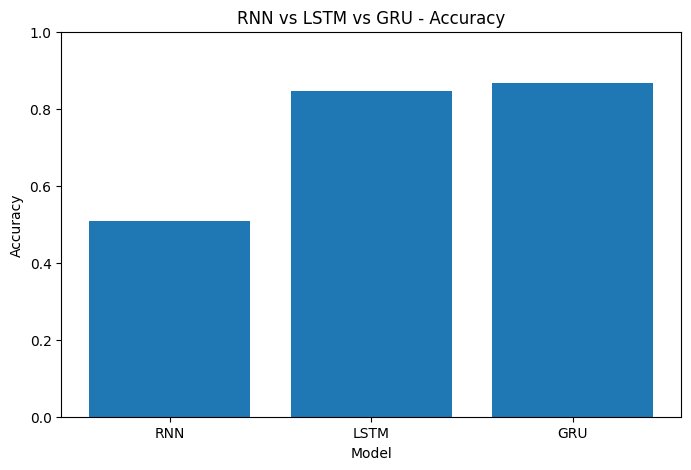

In [26]:
# Cell 25: Accuracy comparison
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("RNN vs LSTM vs GRU - Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

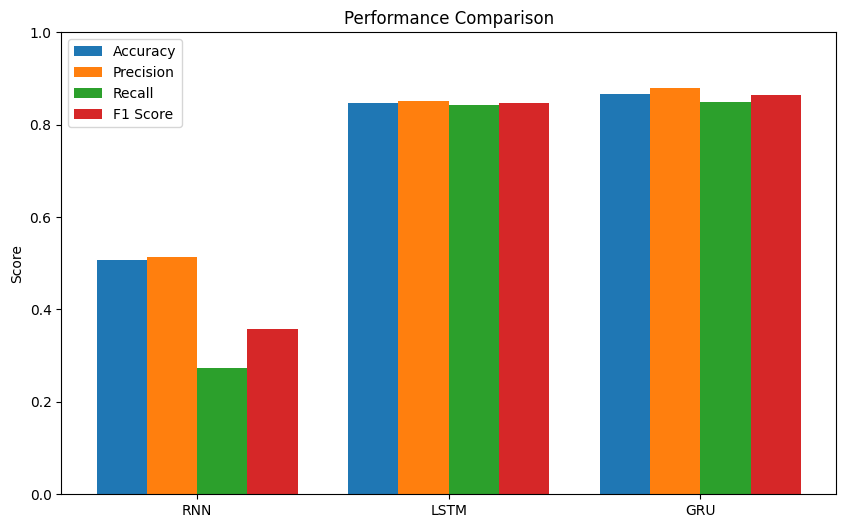

In [27]:
# Cell 26: Compare all evaluation metrics
x = np.arange(len(results_df))
width = 0.2

plt.figure(figsize=(10, 6))

plt.bar(x - 1.5 * width, results_df["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5 * width, results_df["Precision"], width, label="Precision")
plt.bar(x + 0.5 * width, results_df["Recall"], width, label="Recall")
plt.bar(x + 1.5 * width, results_df["F1 Score"], width, label="F1 Score")

plt.xticks(x, results_df["Model"])
plt.ylabel("Score")
plt.title("Performance Comparison")
plt.ylim(0, 1)
plt.legend()

plt.show()

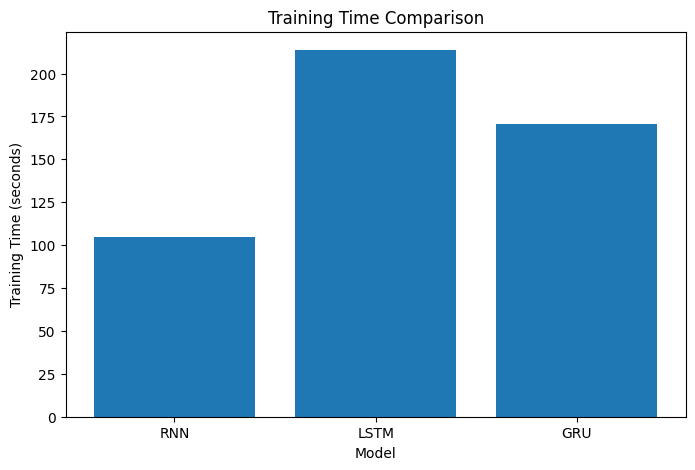

In [28]:
# Cell 27: Training time comparison
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["Training Time (sec)"]
)

plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")

plt.show()

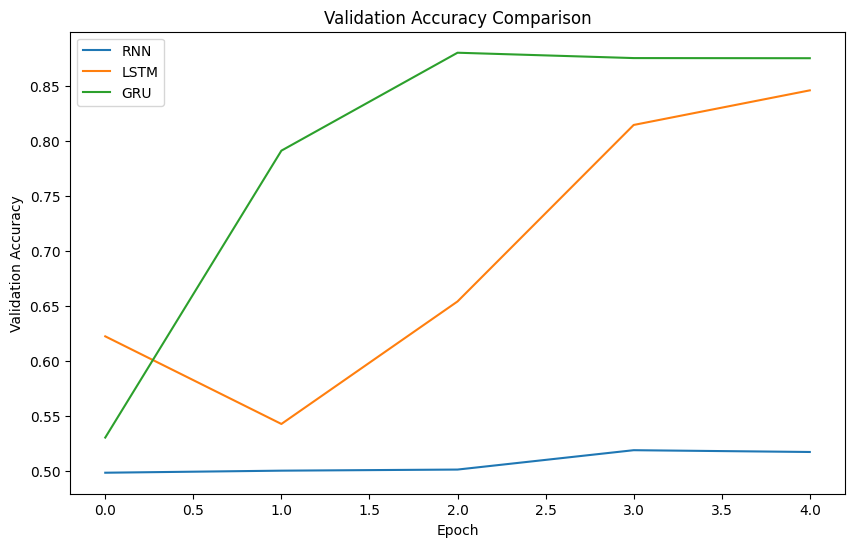

In [29]:
# Cell 28: Validation accuracy comparison
plt.figure(figsize=(10, 6))

plt.plot(rnn_history.history["val_accuracy"], label="RNN")
plt.plot(lstm_history.history["val_accuracy"], label="LSTM")
plt.plot(gru_history.history["val_accuracy"], label="GRU")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.show()

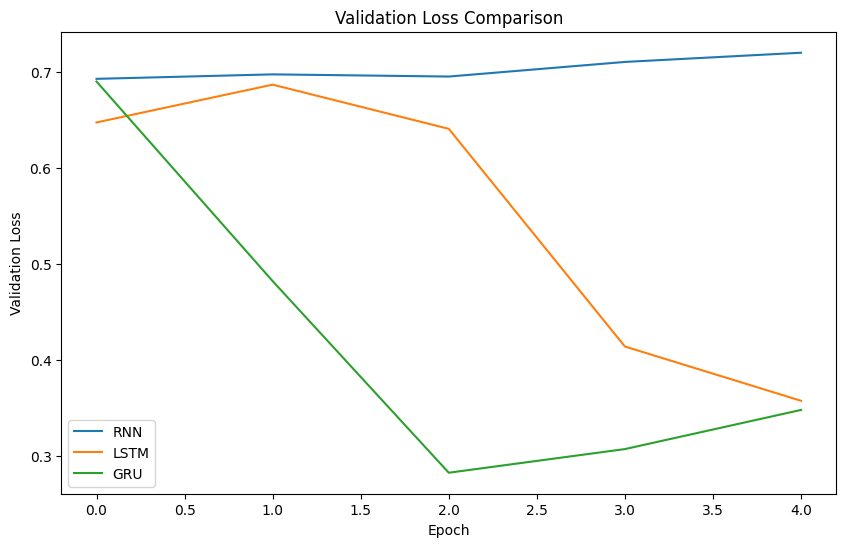

In [30]:
# Cell 29: Validation loss comparison
plt.figure(figsize=(10, 6))

plt.plot(rnn_history.history["val_loss"], label="RNN")
plt.plot(lstm_history.history["val_loss"], label="LSTM")
plt.plot(gru_history.history["val_loss"], label="GRU")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()

plt.show()

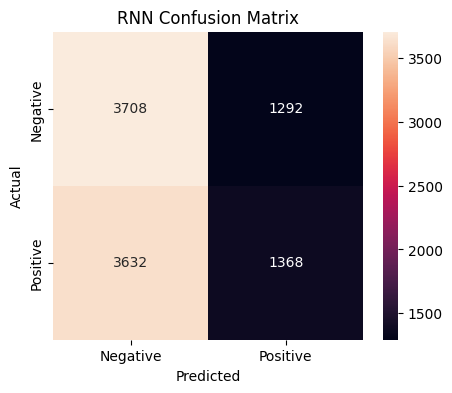

In [31]:
# Cell 30: RNN confusion matrix
cm = confusion_matrix(y_test, rnn_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RNN Confusion Matrix")
plt.show()

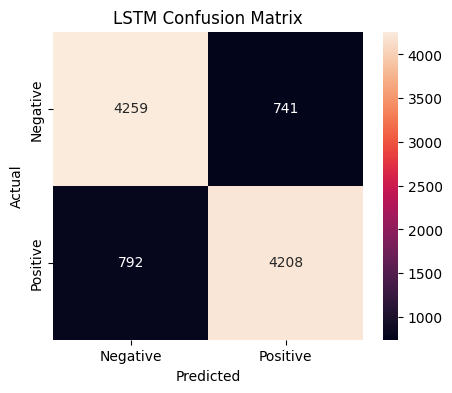

In [32]:
# Cell 31: LSTM confusion matrix
cm = confusion_matrix(y_test, lstm_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")
plt.show()

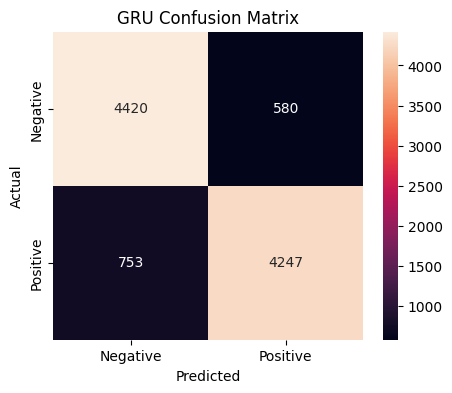

In [33]:
# Cell 32: GRU confusion matrix
cm = confusion_matrix(y_test, gru_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU Confusion Matrix")
plt.show()

In [34]:
# Cell 33: Classification reports
for name, predictions in model_predictions.items():
    print("=" * 60)
    print(f"{name} Classification Report")
    print("=" * 60)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=["Negative", "Positive"],
            zero_division=0
        )
    )

RNN Classification Report
              precision    recall  f1-score   support

    Negative       0.51      0.74      0.60      5000
    Positive       0.51      0.27      0.36      5000

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.48     10000
weighted avg       0.51      0.51      0.48     10000

LSTM Classification Report
              precision    recall  f1-score   support

    Negative       0.84      0.85      0.85      5000
    Positive       0.85      0.84      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

GRU Classification Report
              precision    recall  f1-score   support

    Negative       0.85      0.88      0.87      5000
    Positive       0.88      0.85      0.86      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     1

In [35]:
# Cell 34: Custom sentiment prediction function
def predict_sentiment(model, review):
    sequence = tokenizer.texts_to_sequences([review])

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

    probability = model.predict(padded, verbose=0)[0][0]

    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    return sentiment, float(probability)

In [36]:
# Cell 35: Test a positive review
review = "This movie was absolutely fantastic. The acting was excellent and the story was amazing."

print("Review:", review)

for name, model in [
    ("RNN", rnn_model),
    ("LSTM", lstm_model),
    ("GRU", gru_model)
]:
    sentiment, probability = predict_sentiment(model, review)
    print(f"{name}: {sentiment} | Probability: {probability:.4f}")

Review: This movie was absolutely fantastic. The acting was excellent and the story was amazing.
RNN: Negative | Probability: 0.4674
LSTM: Positive | Probability: 0.8530
GRU: Positive | Probability: 0.9989


In [37]:
# Cell 36: Test a negative review
review = "This movie was extremely boring and disappointing. The acting was terrible."

print("Review:", review)

for name, model in [
    ("RNN", rnn_model),
    ("LSTM", lstm_model),
    ("GRU", gru_model)
]:
    sentiment, probability = predict_sentiment(model, review)
    print(f"{name}: {sentiment} | Probability: {probability:.4f}")

Review: This movie was extremely boring and disappointing. The acting was terrible.
RNN: Negative | Probability: 0.4674
LSTM: Negative | Probability: 0.0834
GRU: Negative | Probability: 0.0028
